In [1]:
import lmdb
import cv2
import os
import json
from tqdm import tqdm
from torch.utils.data import Dataset
import io
from PIL import Image

# Converting Your Data To LMDB

In [2]:
def get_dir_size(path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if os.path.isfile(fp):
                total_size += os.path.getsize(fp)
    return total_size

def create_lmdb_from_folders(img_dir, gt_dir, lmdb_path, ext="png"):

    lmdb_size = get_dir_size(img_dir)+get_dir_size(gt_dir)
    lmdb_size = round(lmdb_size * 1.05) # You may need to increase the size of the lmdb file if you get "Environment mapsize limit reached"
    print(lmdb_size/(1024*1024))
    
    # Create LMDB environment (1TB map size for safety)
    env = lmdb.open(lmdb_path, map_size=lmdb_size)

    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(f'.{ext}')]
    img_files.sort()
    print(f"Found {len(img_files)} image files")

    with env.begin(write=True) as txn:
        for idx, img_name in enumerate(img_files):
            
            base_name = os.path.splitext(img_name)[0]
            img_path = os.path.join(img_dir, img_name)
            gt_path = os.path.join(gt_dir, base_name + ".txt")
    
            # Read image as raw bytes (no quality loss)
            with open(img_path, "rb") as f:
                img_bin = f.read()
    
            # Read GT text
            with open(gt_path, "r", encoding="utf-8") as f:
                text = f.read().strip()
    
            # Keys
            img_key = f"image-{base_name}".encode()
            gt_key = f"label-{base_name}".encode()
    
            # Store into LMDB
            txn.put(img_key, img_bin)
            txn.put(gt_key, text.encode())
    
        # Save dataset size
        txn.put("num-samples".encode(), str(idx + 1).encode())
    
    print(f"✅ Created LMDB at: {lmdb_path}")


In [5]:
split = "train"

img_dir = f"../../../DATASETS/IAM/line_splits/{split}/images"
print(img_dir)
gt_path = f"../../../DATASETS/IAM/line_splits/{split}/gt_text"
lmdb_path = f"../../../DATASETS/IAM/line_splits/{split}/lmdb"
os.makedirs(lmdb_path, exist_ok=True)

create_lmdb_from_folders(img_dir, gt_path, lmdb_path, "png")

../../../DATASETS/IAM/line_splits/train/images
267.1838712692261
Found 5695 image files
✅ Created LMDB at: ../../../DATASETS/IAM/line_splits/train/lmdb


# Access Your Data from LMDB

For this or that particular purpose, the Legislature
1415


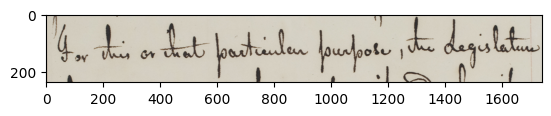

In [4]:
import lmdb
import io
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

lmdb_path = f"../../../DATASETS/IAM/line_splits/train/lmdb"
lmdb_path = f"../../../DATASETS/Bentham/box_lines_dataset/val/lmdb"

env = lmdb.open(lmdb_path, readonly=True, lock=False)
keys = []
with env.begin() as txn:
    cursor = txn.cursor()  # create a cursor to iterate

    for key, value in cursor:
        key_str = key.decode()  # convert bytes -> string
        if key_str.startswith("image-"):
            keys.append(key_str[6:])

idx = 44
with env.begin() as txn:
    img_key = f"image-{keys[idx]}".encode()
    gt_key = f"label-{keys[idx]}".encode()

    img_bin = txn.get(img_key)
    label = txn.get(gt_key).decode()

print(label)

img = Image.open(io.BytesIO(img_bin)).convert("RGB")
plt.imshow(np.array(img))
# img.show()
print(len(keys))

In [23]:
len(keys)

1415

In [14]:
print(type(img))
print(img.size)

<class 'PIL.Image.Image'>
(2605, 306)


# Sample DataLoader

In [ ]:
import glob
import os

import numpy as np
import torch
from skimage import io
from torch.utils.data import Dataset

from src.data.image.img_preprocess import image_resize, centered_img
from src.data.text.read_txt_util import Text_Reader
import lmdb
import io
from PIL import Image


class HTRDataset(Dataset):
    """

    """

    def __init__(self,
                 dir_data: str,
                 fixed_size,
                 width_divisor,
                 pad_left,
                 pad_right,
                 text_read: Text_Reader,
                 transforms: list = None,
                 ext_img: str = "png",
                 apply_noise: int = 0,
                 is_trainset=False):
        """
        """

        self.keys = []

        self.text_read = text_read

        self.fixed_size = fixed_size
        self.transforms = transforms
        self.pad_left = pad_left
        self.pad_right = pad_right

        self.width_divisor = width_divisor

        self.apply_noise = apply_noise
        self.is_trainset = is_trainset

        self.lmdb_path = os.path.join(dir_data, "lmdb")
        self.env = None   # IMPORTANT: do NOT open LMDB here

        # Read keys ONLY using a temporary env
        tmp_env = lmdb.open(self.lmdb_path, readonly=True, lock=False)
        
        with tmp_env.begin() as txn:
            cursor = txn.cursor()  # create a cursor to iterate

            for key, value in cursor:
                key_str = key.decode()  # convert bytes -> string
                if key_str.startswith("image-"):
                    self.keys.append(key_str[6:])
        tmp_env.close()



    def __len__(self):
        """
        Returns the number of images in the dataset
        Returns
        -------
        length: int
            number of images in the dataset
        """

        return len(self.keys)

    def __getitem__(self, idx):
        """
        """
        if self.env is None:
            self.env = lmdb.open(self.lmdb_path, readonly=True, lock=False)

        with self.env.begin() as txn:
            img_key = f"image-{self.keys[idx]}".encode()
            gt_key = f"label-{self.keys[idx]}".encode()
            line_id = self.keys[idx]

            img_bin = txn.get(img_key)
            label_str = txn.get(gt_key).decode() # string


        img = Image.open(io.BytesIO(img_bin)).convert("L")  # Convert to grayscale
        label_str = self.text_read.read_text2(label_str)
        labels_ind = self.text_read.transcript_txt_to_index(label_str)

        img = np.array(img)

        # Binarize img
        if img.dtype == bool:
            img = img.astype(int)
            img *= 255
            print("Binarized img detected. Converted to uint8")

        if np.max(img) <= 1:
            img = (img * 255).astype(int)

        # print(np.min(img), np.max(img))
        # print("img shape:", img.shape)


        # Resize and pad
        img = 1 - img.astype(np.float32) / 255.0
        img = np.clip(img, 0, 1)

        fheight, fwidth = self.fixed_size[0], self.fixed_size[1]

        # # https://github.com/georgeretsi/HTR-best-practices/blob/main/utils/transforms.py
        if self.is_trainset:
            nwidth = int(np.random.uniform(.75, 1.25) * img.shape[1])
            nheight = int((np.random.uniform(.9, 1.1) * img.shape[0] / img.shape[1]) * nwidth)
        else:
            nheight, nwidth = img.shape[0], img.shape[1]

        nheight, nwidth = max(4, min(fheight-16, nheight)), max(8, min(fwidth-32, nwidth))
        img = image_resize(img, height=int(1.0 * nheight), width=int(1.0 * nwidth))

        img = centered_img(img, (fheight, fwidth), border_value=0.0)

        img = np.pad(img, ((0, 0), (self.pad_left, self.pad_right)), 'constant', constant_values=0)

        # Augmentation
        if self.transforms is not None:
            img = self.transforms(image=img)['image']

        imgs_shape = img.shape
        w_reduce = np.floor(imgs_shape[1] / self.width_divisor).astype(int)

        img_tensor = torch.as_tensor(img, dtype=torch.float32)

        if self.apply_noise == 1:
            if np.random.rand() < .33:
                img_tensor += torch.rand(img_tensor.size())

        img_tensor = img_tensor.unsqueeze(0)  # Add channel dim

        sample = {
            "ids": line_id,

            "label_str": label_str,
            "label_ind": labels_ind,

            "img": img_tensor,
            "w_reduce": w_reduce
        }


        return sample